# PTM viewer testing

In [1]:
from ptm_notebook_tools import plot_projections, plot_3d, load_ptm_mat, plot_all, plot_projections, plot_3d, launch

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.io import loadmat

import pandas as pd


E:\Uni\Cardiff\Anaconda\envs\hyperspy_env\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
%matplotlib qt5

## Editing in 3D

In [71]:
xyz, masks, scores, threshold = load_ptm_mat("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot.mat")

In [72]:
launch((xyz, masks))

## Filtering Dataframes

In [3]:
mattest = loadmat("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot.mat")
ptm = mattest['PTMResult'][0,0]

In [4]:
d = np.load("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot_ManualClean.npz")
xyz = d["xyz"]
masks = {
"FCC": d["ind_fcc"].astype(bool),
"HCP": d["ind_hcp"].astype(bool),
"DH": d["ind_dh"].astype(bool),
"IH": d["ind_ih"].astype(bool),
"Chaos": d["ind_chaos"].astype(bool),
}

In [14]:
ptmdf = pd.DataFrame({
    "x": ptm["xyz"][:, 0],
    "y": ptm["xyz"][:, 1],
    "z": ptm["xyz"][:, 2],

    "FCCscore": ptm["FCCscore"].flatten(),
    "HCPscore": ptm["HCPscore"].flatten(),
    "DHscore": ptm["DHscore"].flatten(),
    "IHscore": ptm["IHscore"].flatten(),

    "ind_fcc": ptm["ind_fcc"].flatten(),
    "ind_hcp": ptm["ind_hcp"].flatten(),
    "ind_dh": ptm["ind_dh"].flatten(),
    "ind_ih": ptm["ind_ih"].flatten(),
    "ind_chaos": ptm["ind_chaos"].flatten()
})

In [15]:
assigned_mask = (
    (ptmdf["ind_fcc"] == 1) |
    (ptmdf["ind_hcp"] == 1) |
    (ptmdf["ind_dh"] == 1) |
    (ptmdf["ind_ih"] == 1)
)

chaos_mask = ptmdf["ind_chaos"] == 1
print((assigned_mask & chaos_mask).sum()) # check they are mutually exclsuive
score_cols = ["FCCscore", "HCPscore", "DHscore", "IHscore"]
ptmdf["best_structure"] = ptmdf[score_cols].idxmax(axis=1)
ptmdf["best_structure"] = ptmdf["best_structure"].str.replace("score", "")
fcc_mask = ptmdf["ind_fcc"] == 1
non_fcc_assigned = assigned_mask & (ptmdf["ind_fcc"] == 0)
chaos_fcc_like = chaos_mask & (ptmdf["best_structure"] == "FCC")
chaos_non_fcc_like = chaos_mask & (ptmdf["best_structure"] != "FCC")
ptmdf["category"] = "unclassified"

ptmdf.loc[fcc_mask, "category"] = "FCC"
ptmdf.loc[non_fcc_assigned, 'category'] = ptmdf.loc[non_fcc_assigned, 'best_structure']
ptmdf.loc[chaos_fcc_like, "category"] = "Chaos (FCC-like)"
ptmdf.loc[chaos_non_fcc_like, "category"] = "Chaos (non-FCC-like)"

print(ptmdf["category"].value_counts())
print(len(ptmdf), ptmdf["category"].notna().sum())

0
category
FCC                     2390
Chaos (FCC-like)        1489
Chaos (non-FCC-like)     444
HCP                       43
Name: count, dtype: int64
4366 4366


In [16]:
# match coordinates first
tree = cKDTree(ptmdf[["x","y","z"]].values)
# get idx of tree that match coords for filtered version
_, idx = tree.query(d["xyz"], k=1)

ptmdf_filtered = ptmdf.iloc[idx].copy()

In [46]:
# center for plotting/realign with tilt axes - cahnging software can cause changing axes labels
xyz = ptmdf_filtered[["x","y","z"]].values
center = xyz.mean(axis=0)

xyz_centered = xyz - center

# 90 rotation around Y-axis: (X, Y, Z) → (Z, Y, -X)
xyz_rotated = np.column_stack([
    xyz_centered[:, 2],   # Z becomes new X
    xyz_centered[:, 1],   # Y stays as new Y (no flip)
    -xyz_centered[:, 0]   # -X becomes new Z
])

# 180 rotation around X-axis: (X, Y, Z) → (X, -Y, -Z)
xyz_180 = np.column_stack([
    xyz_rotated[:, 0],
    -xyz_rotated[:, 1],
    -xyz_rotated[:, 2]
])

# Shift back to center
xyz_corrected = xyz_180 + center

# Apply to dataframe
ptmdf_filtered['x'] = xyz_corrected[:, 0]
ptmdf_filtered['y'] = xyz_corrected[:, 1]
ptmdf_filtered['z'] = xyz_corrected[:, 2]

In [47]:
ptmdf_filtered.to_csv("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot_ManualClean2.csv", index=False)

In [54]:
print(ptmdf_filtered["category"].value_counts())
print(len(ptmdf_filtered), ptmdf_filtered["category"].notna().sum())

category
FCC                     2390
Chaos (FCC-like)        1395
Chaos (non-FCC-like)     380
HCP                       43
Name: count, dtype: int64
4208 4208


## Plotting 2D

In [3]:
ptmdf_filtered = pd.read_csv("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot_ManualClean2.csv")

In [4]:
ptmdf_filtered

,x,y,z,FCCscore,HCPscore,DHscore,IHscore,ind_fcc,ind_hcp,ind_dh,ind_ih,ind_chaos,best_structure,category
0,64.320069,23.166685,13.843133,7.195350,6.822605,3.807056,4.107688,0,0,0,0,1,FCC,Chaos (FCC-like)
1,38.380000,45.607627,14.494596,2.255372,2.255372,1.859852,1.970861,0,0,0,0,1,FCC,Chaos (FCC-like)
2,34.546302,45.690167,14.876196,1.782497,1.782497,2.076830,1.978438,0,0,0,0,1,DH,Chaos (non-FCC-like)
3,38.337502,38.170090,14.876196,3.427126,3.427126,2.617713,3.287687,0,0,0,0,1,FCC,Chaos (FCC-like)
4,42.431703,37.802457,14.927670,3.709804,3.709804,3.203039,3.177370,0,0,0,0,1,FCC,Chaos (FCC-like)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4203,48.880396,56.684941,96.400724,3.753425,3.753425,3.234338,3.354871,0,0,0,0,1,FCC,Chaos (FCC-like)
4204,52.964531,56.713141,96.650405,3.574353,3.574353,2.743229,3.251121,0,0,0,0,1,FCC,Chaos (FCC-like)
4205,54.633001,53.610046,97.615395,0.956331,0.956331,1.786701,1.730387,0,0,0,0,1,DH,Chaos (non-FCC-like)
4206,54.861274,63.123498,98.392714,1.850695,1.850695,1.868351,1.718019,0,0,0,0,1,DH,Chaos (non-FCC-like)


In [5]:
masks = {
    'FCC': ptmdf_filtered['category'] == 'FCC',
    'HCP': ptmdf_filtered['category'] == 'HCP',
    'DH': ptmdf_filtered['category'] == 'DH',
    'IH': ptmdf_filtered['category'] == 'IH',
    'Chaos (FCC-like)': ptmdf_filtered['category'] == 'Chaos (FCC-like)',
    'Chaos (non-FCC-like)': ptmdf_filtered['category'] == 'Chaos (non-FCC-like)',
    'Non-FCC assigned': ptmdf_filtered['category'] == 'Non-FCC assigned'
}
xyz = ptmdf_filtered[["x","y","z"]].values

In [7]:
#xyz, masks = load_ptm_mat("Ceonly_4366_d4_wienerfilt_AsymPTMResult50_OGrot.mat")
fig = plot_projections((xyz, masks), save_path=r"PTM2DFigure_1.png")
plt.show()

fig = plot_all((xyz, masks), elev=20, azim=35, save_path=r"PTMallFigure_2.png")
plt.show()


Saved -> C:\Users\ellak\Downloads\PTM2DFigure_1.png (dpi=1000)
Saved -> C:\Users\ellak\Downloads\PTMallFigure_2.png (dpi=1000)


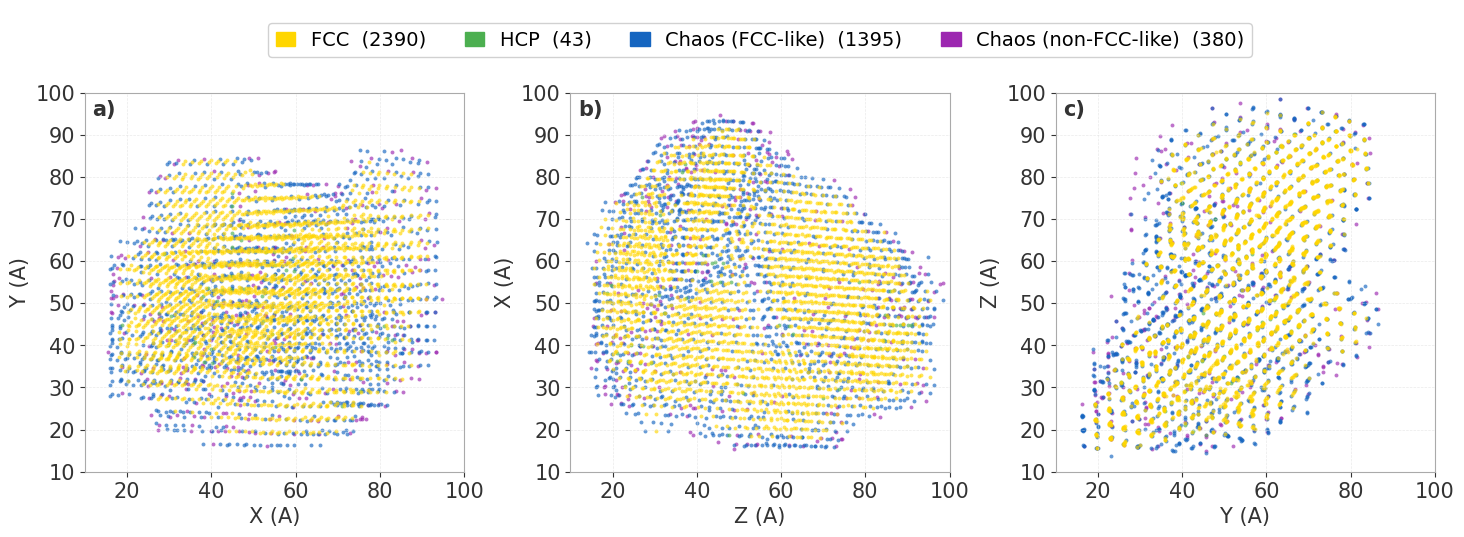

In [6]:
plot_projections((xyz, masks), labelplot= True)